# Проверка модели и внешних факторов

Прогноз на сентябрь–октябрь 2025 получен из истории до 31 августа. Финальное обучение
для ноябрь–декабрь использует январь–октябрь. Здесь проверяется сохранённая конфигурация:
98% сезонного медианного профиля и 2% LightGBM MAE. №5 не входит в локальные метрики,
поскольку фактической истории для него нет.

Осенний период использовался при разработке: результаты диагностические, не оценка
нового независимого теста. Эксперименты с источниками оцениваются отдельно от основного
прогноза и от скрытой платформы.

In [1]:
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.figure import Figure

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "ml/reports").is_dir())
REPORTS = ROOT / "ml/reports"
FIGURES = ROOT / "ml/reports/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "figure.figsize": (11, 5),
        "axes.grid": True,
        "grid.alpha": 0.18,
        "axes.axisbelow": True,
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
    }
)
BLUE, TEAL, ORANGE = "#234E70", "#008A85", "#D57433"


def finish(fig: Figure, name: str) -> None:
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

## 1. Пересчёт метрик из почасовых предсказаний

In [2]:
frame = pd.read_csv(REPORTS / "eda/validation_predictions.csv", sep=";", parse_dates=["date"])
assert len(frame) == 13176 and 5 not in set(frame.route)
assert not frame.duplicated(["route", "date", "hour"]).any()
frame["error"] = frame.prediction - frame.boardings
frame["absolute_error"] = frame.error.abs()
frame["baseline_absolute_error"] = (frame.baseline_prediction - frame.boardings).abs()
score = 1 - frame.absolute_error.sum() / frame.boardings.sum()
assert np.isclose(score, 0.8920614645158826, atol=1e-12, rtol=0)
metrics = pd.DataFrame(
    {
        "MAE": [frame.baseline_absolute_error.mean(), frame.absolute_error.mean()],
        "WAPE-score": [1 - frame.baseline_absolute_error.sum() / frame.boardings.sum(), score],
    },
    index=["Среднее: маршрут × день недели × час", "Гибридная модель"],
)
display(metrics.round(6))

,MAE,WAPE-score
Среднее: маршрут × день недели × час,133.298837,0.862296
Гибридная модель,104.485428,0.892061


## 2. Ошибки по маршрутам и времени

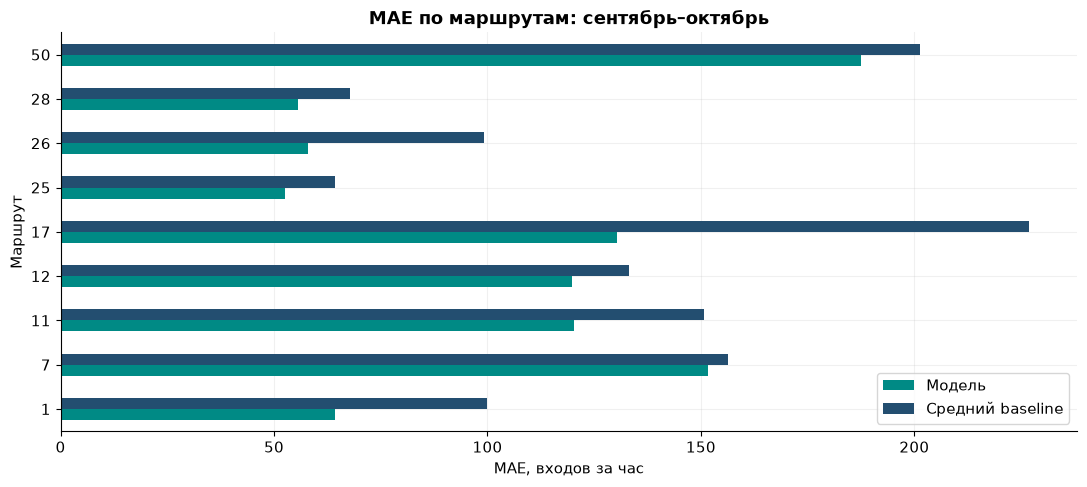

In [3]:
errors = frame.groupby("route")[["absolute_error", "baseline_absolute_error"]].mean()
fig, ax = plt.subplots(figsize=(11, 5))
errors.rename(
    columns={"absolute_error": "Модель", "baseline_absolute_error": "Средний baseline"}
).plot.barh(ax=ax, color=[TEAL, BLUE])
ax.set(xlabel="MAE, входов за час", ylabel="Маршрут", title="MAE по маршрутам: сентябрь–октябрь")
finish(fig, "08_route_validation_mae")

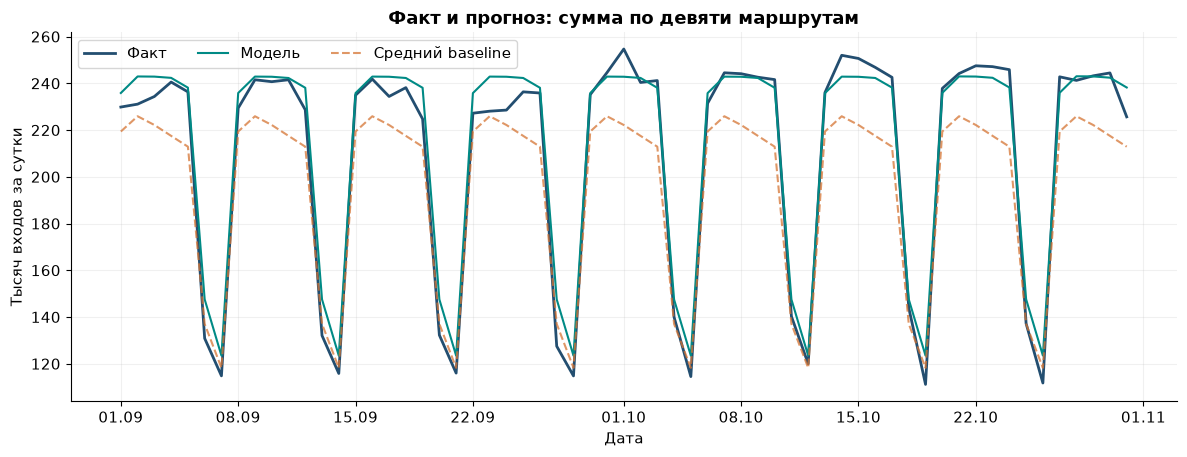

model_mae_route_day                                        1662.943534
baseline_mae_route_day                                     2497.920447
scope                     route-day sums, not hourly submission metric
dtype: object

In [4]:
daily = frame.groupby("date")[["boardings", "prediction", "baseline_prediction"]].sum()
fig, ax = plt.subplots(figsize=(12, 4.7))
ax.plot(daily.index, daily.boardings / 1000, color=BLUE, label="Факт", linewidth=2)
ax.plot(daily.index, daily.prediction / 1000, color=TEAL, label="Модель", linewidth=1.5)
ax.plot(
    daily.index,
    daily.baseline_prediction / 1000,
    color=ORANGE,
    label="Средний baseline",
    alpha=0.75,
    linestyle="--",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.set(
    xlabel="Дата", ylabel="Тысяч входов за сутки", title="Факт и прогноз: сумма по девяти маршрутам"
)
ax.legend(ncol=3)
finish(fig, "09_actual_vs_forecast")
by_route_day = frame.groupby(["route", "date"])[
    ["boardings", "prediction", "baseline_prediction"]
].sum()
daily_metrics = {
    "model_mae_route_day": float((by_route_day.prediction - by_route_day.boardings).abs().mean()),
    "baseline_mae_route_day": float(
        (by_route_day.baseline_prediction - by_route_day.boardings).abs().mean()
    ),
    "scope": "route-day sums, not hourly submission metric",
}
display(pd.Series(daily_metrics))

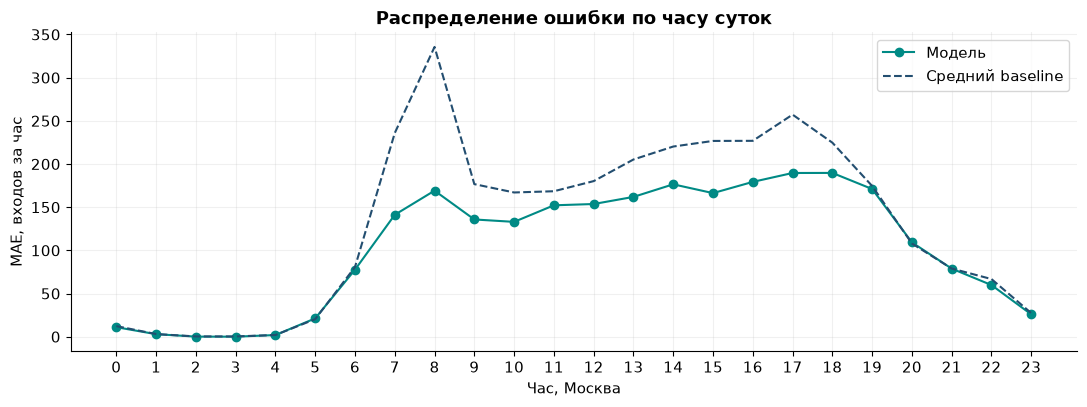

In [5]:
by_hour = frame.groupby("hour")[["absolute_error", "baseline_absolute_error"]].mean()
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(by_hour.index, by_hour.absolute_error, color=TEAL, marker="o", label="Модель")
ax.plot(
    by_hour.index,
    by_hour.baseline_absolute_error,
    color=BLUE,
    linestyle="--",
    label="Средний baseline",
)
ax.set(
    xticks=range(24),
    xlabel="Час, Москва",
    ylabel="MAE, входов за час",
    title="Распределение ошибки по часу суток",
)
ax.legend()
finish(fig, "10_hourly_error")

Суточная агрегация сглаживает почасовые ошибки и не заменяет метрику сабмита.
Проверка включает все 24 часа. Аномальные дни не удаляются. Для каждого маршрута
используются одинаковые даты и часы при сравнении с baseline.

## 3. Совместное влияние четырёх источников

,rows,mae,wape_score,absolute_error
variant,,,,
with_four_sources,39744,123.188330,0.860226,4895997
without_external_sources,39744,138.765197,0.842552,5515084


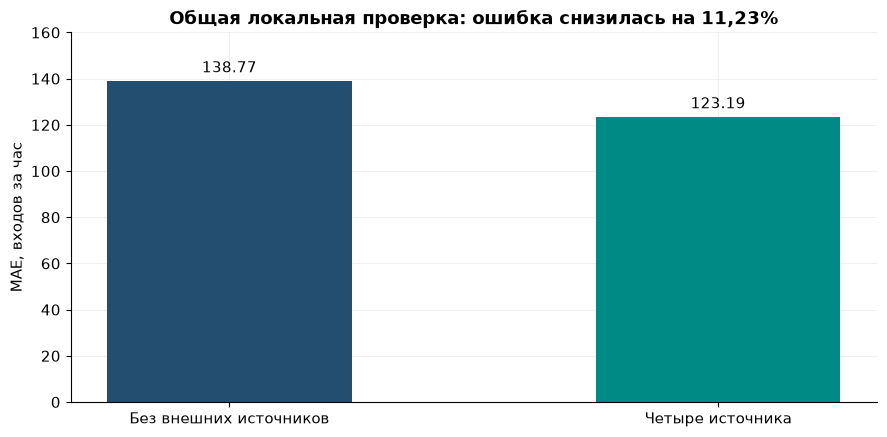

In [6]:
summary = pd.read_csv(REPORTS / "champion/overall_source_effect/summary.csv", sep=";").set_index(
    "variant"
)
assert summary.rows.eq(39744).all()
for _, row in summary.iterrows():
    assert np.isclose(row.wape_score, 1 - row.absolute_error / row.target_sum)
display(summary[["rows", "mae", "wape_score", "absolute_error"]].round(6))
order = ["without_external_sources", "with_four_sources"]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(
    ["Без внешних источников", "Четыре источника"],
    summary.loc[order, "mae"],
    color=[BLUE, TEAL],
    width=0.5,
)
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set(
    ylim=(0, 160),
    ylabel="MAE, входов за час",
    title="Общая локальная проверка: ошибка снизилась на 11,23%",
)
finish(fig, "11_external_sources_overall")

Open-Meteo, XMLCalendar, KudaGo и архив ДТП сравнивались с вариантом без внешних источников
при одинаковых настройках. Оценены все доступные блоки исходной схемы: май–июнь,
июль–август и сентябрь–октябрь, 39 744 маршрут-часа. Итог рассчитан по суммам ошибок,
а не средним месячных score. OSM и дорожная эвристика исключены из обоих вариантов.
Совместный выигрыш не устанавливает положительную пользу каждого источника отдельно.

## 4. Устойчивость эффекта и индивидуальные абляции

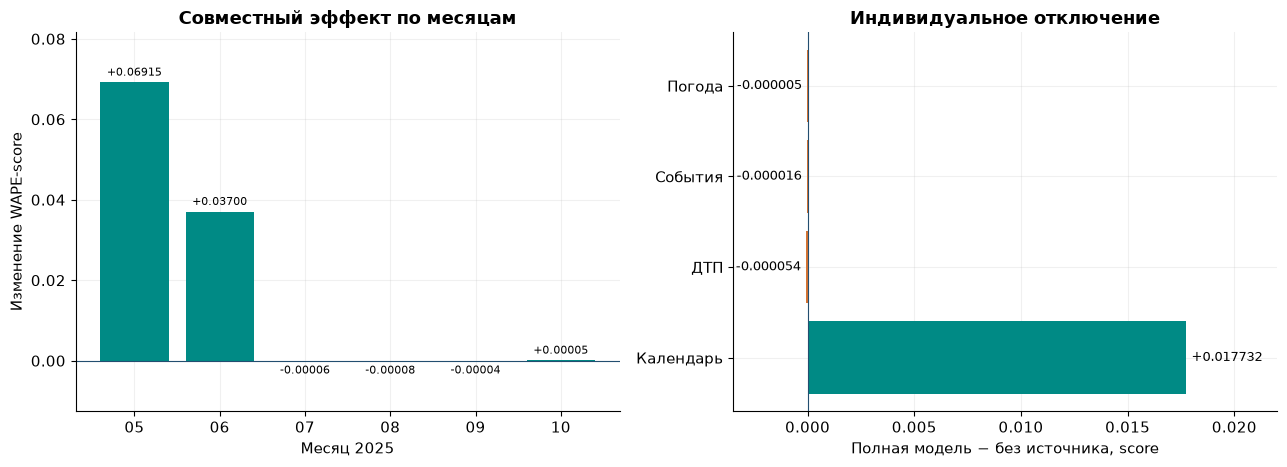

,period,full_minus_variant
1,2025-05,0.069152
7,2025-06,0.037003
13,2025-07,-0.000058
19,2025-08,-0.000080
25,2025-09,-0.000039
31,2025-10,0.000051


,variant,full_minus_variant
38,without_calendar,0.017732
39,without_crashes,-0.000054
40,without_events,-0.000016
41,without_weather,-0.000005


In [7]:
scores = pd.read_csv(REPORTS / "champion/source_effects/scores.csv", sep=";")
monthly = scores[
    scores.variant.eq("without_all_four") & scores.period.str.match(r"2025-\d{2}$")
].copy()
individual = scores[
    scores.period.eq("all_six_months")
    & scores.variant.isin(
        ["without_weather", "without_calendar", "without_events", "without_crashes"]
    )
].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
month_bars = axes[0].bar(
    monthly.period.str[-2:],
    monthly.full_minus_variant,
    color=[TEAL if v >= 0 else ORANGE for v in monthly.full_minus_variant],
)
axes[0].bar_label(
    month_bars, labels=[f"{v:+.5f}" for v in monthly.full_minus_variant], padding=3, fontsize=8
)
axes[0].margins(y=0.18)
axes[0].axhline(0, color=BLUE, linewidth=0.8)
axes[0].set(
    xlabel="Месяц 2025", ylabel="Изменение WAPE-score", title="Совместный эффект по месяцам"
)
labels = {
    "without_weather": "Погода",
    "without_calendar": "Календарь",
    "without_events": "События",
    "without_crashes": "ДТП",
}
source_bars = axes[1].barh(
    individual.variant.map(labels),
    individual.full_minus_variant,
    color=[TEAL if v >= 0 else ORANGE for v in individual.full_minus_variant],
)
axes[1].bar_label(
    source_bars, labels=[f"{v:+.6f}" for v in individual.full_minus_variant], padding=4, fontsize=9
)
axes[1].set_xlim(-0.0035, 0.022)
axes[1].axvline(0, color=BLUE, linewidth=0.8)
axes[1].set(xlabel="Полная модель − без источника, score", title="Индивидуальное отключение")
finish(fig, "12_source_effect_stability")
display(monthly[["period", "full_minus_variant"]])
display(individual[["variant", "full_minus_variant"]])

Это вспомогательное сравнение сохраняет дорожную эвристику в обоих вариантах, поэтому его
значения немного отличаются от строгого сравнения выше. Все месяцы показаны, включая
ухудшения. Основной совместный эффект связан с календарём; отдельное удаление событий
и ДТП немного улучшает результат. Статистическая значимость малых различий не установлена.

Критерий хакатона выделяет категории «трафик», «погода», «календарь» и «прочие факторы».
События и ДТП относятся к дополнительным факторам; четыре API не означают автоматического
закрытия четырёх категорий. Измеренные дорожные заторы в данном артефакте отсутствуют.

## 5. Признаки, используемые бустингом

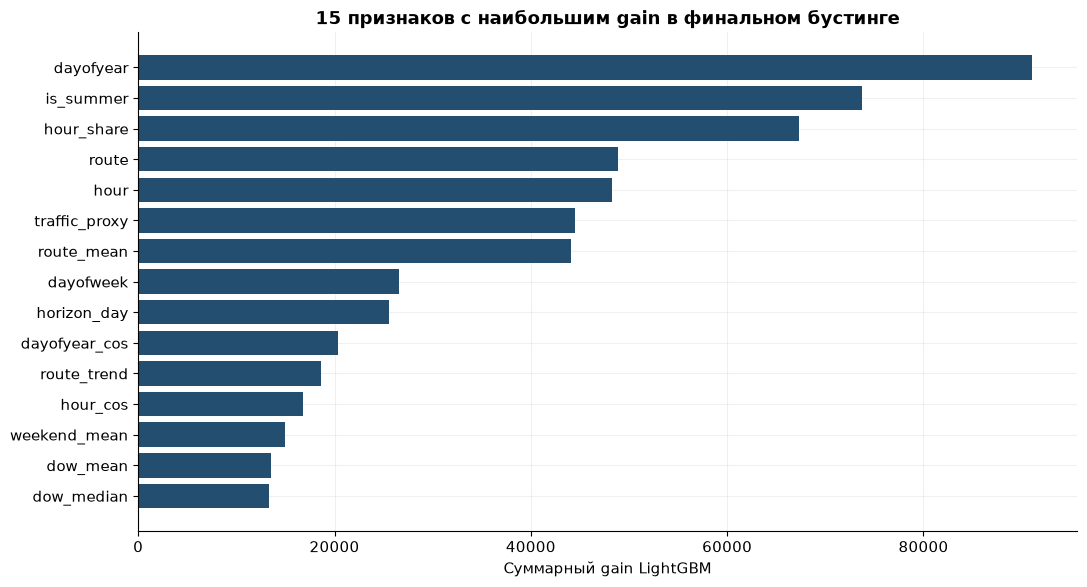

In [8]:
importance = pd.read_csv(REPORTS / "champion/feature_importance.csv", sep=";")
top = importance.sort_values("gain").tail(15)
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top.feature, top.gain, color=BLUE)
ax.set(
    xlabel="Суммарный gain LightGBM", title="15 признаков с наибольшим gain в финальном бустинге"
)
finish(fig, "13_feature_importance")

Gain и число разбиений описывают использование признаков внутри деревьев, а не причинный
вклад источников и не долю итогового прогноза. Сам бустинг имеет вес 2%; календарная
поправка также действует в сезонной части. Коридоры неопределённости не показываются:
они не откалиброваны для этого сохранённого артефакта.

In [9]:
result = {
    "hourly_mae": float(frame.absolute_error.mean()),
    "hourly_wape_score": float(score),
    "baseline_mae": float(frame.baseline_absolute_error.mean()),
    **daily_metrics,
}
(REPORTS / "eda/notebook_metrics.json").write_text(
    json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(pd.Series(result))

hourly_mae                                                  104.485428
hourly_wape_score                                             0.892061
baseline_mae                                                133.298837
model_mae_route_day                                        1662.943534
baseline_mae_route_day                                     2497.920447
scope                     route-day sums, not hourly submission metric
dtype: object